In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
batting_df = pd.read_csv('/content/batting_summary.csv')
bowling_df = pd.read_csv('/content/bowling_summary.csv')
matches_df = pd.read_csv('/content/match_schedule_results.csv')
players_info_df = pd.read_csv('/content/world_cup_players_info.csv')
print("All datasets loaded successfully.")
batting_df.head()
bowling_df.head()
matches_df.head()
players_info_df.head()

All datasets loaded successfully.


,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


In [3]:
# Clean and standardize column names across all datasets
def clean_cols(df):

    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
    return df

batting_df = clean_cols(batting_df)
bowling_df = clean_cols(bowling_df)
matches_df = clean_cols(matches_df)
players_info_df = clean_cols(players_info_df)

In [4]:
# Batting data column renaming
batting_df.rename(columns={
    'match_no': 'match_id',
    'batsman_name': 'batsman',
    'team_innings': 'team',
    'dismissal': 'out_or_not_out',
    'batting_position': 'position'
}, inplace=True)

# Bowling data column renaming
bowling_df.rename(columns={
    'match_no': 'match_id',
    'bowler_name': 'bowler',
    'bowling_team': 'team'
}, inplace=True)

# Matches data column renaming
matches_df.rename(columns={
    'match_no': 'match_id',
    'date': 'date',
    'venue': 'venue',
    'team1': 'team_1',
    'team2': 'team_2',
    'winner': 'winner'
}, inplace=True)

# Players info column renaming
players_info_df.rename(columns={
    'player_name': 'player_name',
    'team_name': 'country',
    'playingrole': 'role'
}, inplace=True)
matches_df['team_1'] = matches_df['team_1'].str.strip()
matches_df['team_2'] = matches_df['team_2'].str.strip()
matches_df['winner'] = matches_df['winner'].str.strip()


Data Cleaning and Text Processing

In [6]:
# Create standardized dismissal status for batting data
# If dismissal is NaN, empty, or contains 'not out', then 'not out', otherwise 'out'
batting_df['out_or_not_out'] = batting_df['out_or_not_out'].apply(
    lambda x: 'not out' if (pd.isna(x) or str(x).strip() == '' or 'not out' in str(x).lower()) else 'out'
)

# Clean player names (remove extra spaces)
batting_df['batsman'] = batting_df['batsman'].str.strip()
bowling_df['bowler'] = bowling_df['bowler'].str.strip()
players_info_df['player_name'] = players_info_df['player_name'].str.strip()

Data Integration and Merging

In [7]:
# Merge batting data with player info to get team/country information
batting_df = pd.merge(
    batting_df,
    players_info_df[['player_name', 'country', 'role']],
    left_on='batsman',
    right_on='player_name',
    how='left'
)
batting_df.rename(columns={'country': 'batsman_country', 'role': 'batsman_role'}, inplace=True)
batting_df.drop(columns=['player_name'], inplace=True)

# Merge bowling data with player info to get team/country information
bowling_df = pd.merge(
    bowling_df,
    players_info_df[['player_name', 'country', 'role']],
    left_on='bowler',
    right_on='player_name',
    how='left'
)
bowling_df.rename(columns={'country': 'bowler_country', 'role': 'bowler_role'}, inplace=True)
bowling_df.drop(columns=['player_name'], inplace=True)

# Check for any missing team information
batting_missing = batting_df['batsman_country'].isna().sum()
bowling_missing = bowling_df['bowler_country'].isna().sum()

if batting_missing > 0 or bowling_missing > 0:
    print(f"Warning: {batting_missing} batting records and {bowling_missing} bowling records missing team info")
else:
    print("All players successfully matched with team information")

All players successfully matched with team information


Numeric Data Type Conversion

In [9]:
# Convert batting statistics to appropriate numeric data types

numeric_cols_batting = ['runs', 'balls', '4s', '6s', 'strike_rate']

for col in numeric_cols_batting:
    if col in batting_df.columns:
        batting_df[col] = pd.to_numeric(batting_df[col], errors='coerce')

# Rename boundary columns for consistency
batting_df.rename(columns={'4s': 'fours', '6s': 'sixes'}, inplace=True)
# Convert bowling statistics to appropriate numeric data types

numeric_cols_bowling = ['overs', 'maidens', 'runs', 'wickets', 'economy']

for col in numeric_cols_bowling:
    if col in bowling_df.columns:
        bowling_df[col] = pd.to_numeric(bowling_df[col], errors='coerce')

Date Processing and Innings Assignment

In [10]:
# Convert 'date' column in matches_df to datetime
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')

# Add innings information to batting data based on team batting order
# Assumption: Team_1 bats first (innings 1), Team_2 bats second (innings 2)
batting_df = pd.merge(batting_df, matches_df[['match_id', 'team_1', 'team_2']], on='match_id', how='left')

def get_innings(row):
    if row['team'] == row['team_1']:
        return 1
    elif row['team'] == row['team_2']:
        return 2
    else:
        return 1  # default

batting_df['innings'] = batting_df.apply(get_innings, axis=1)
batting_df.drop(columns=['team_1', 'team_2'], inplace=True)

/tmp/ipython-input-1814577941.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')


Data Preprocessing Summary

In [11]:
print("The data after processing:")

print("Batting Summary")
print(batting_df.head())

print("Bowling Summary")
print(bowling_df.head())

print("Match Schedule")
print(matches_df.head())

print("Players Info:")
print(players_info_df.head())

The data after processing:
Batting Summary
   match_id           match_between     team         batsman  position  \
0         1  England vs New Zealand  England  Jonny Bairstow         1   
1         1  England vs New Zealand  England     Dawid Malan         2   
2         1  England vs New Zealand  England        Joe Root         3   
3         1  England vs New Zealand  England     Harry Brook         4   
4         1  England vs New Zealand  England       Moeen Ali         5   

  out_or_not_out  runs  balls  fours  sixes  strike_rate batsman_country  \
0            out    33     35      4      1         94.3         England   
1            out    14     24      2      0         58.3         England   
2            out    77     86      4      1         89.5         England   
3            out    25     16      4      1        156.3         England   
4            out    11     17      1      0         64.7         England   

          batsman_role  innings  
0  Wicketkeeper Batte

Team Analysis

Team Win Percentage:
                      Team  Wins  Matches Played      Win %
winner                                                     
Australia        Australia     9              11  81.818182
India                India     9              11  81.818182
South Africa  South Africa     7              10  70.000000
New Zealand    New Zealand     5              10  50.000000
Pakistan          Pakistan     4               9  44.444444
Afghanistan    Afghanistan     4               9  44.444444
Sri Lanka        Sri Lanka     3               9  33.333333
England            England     3               9  33.333333
Bangladesh      Bangladesh     2               9  22.222222
Netherlands    Netherlands     2               9  22.222222


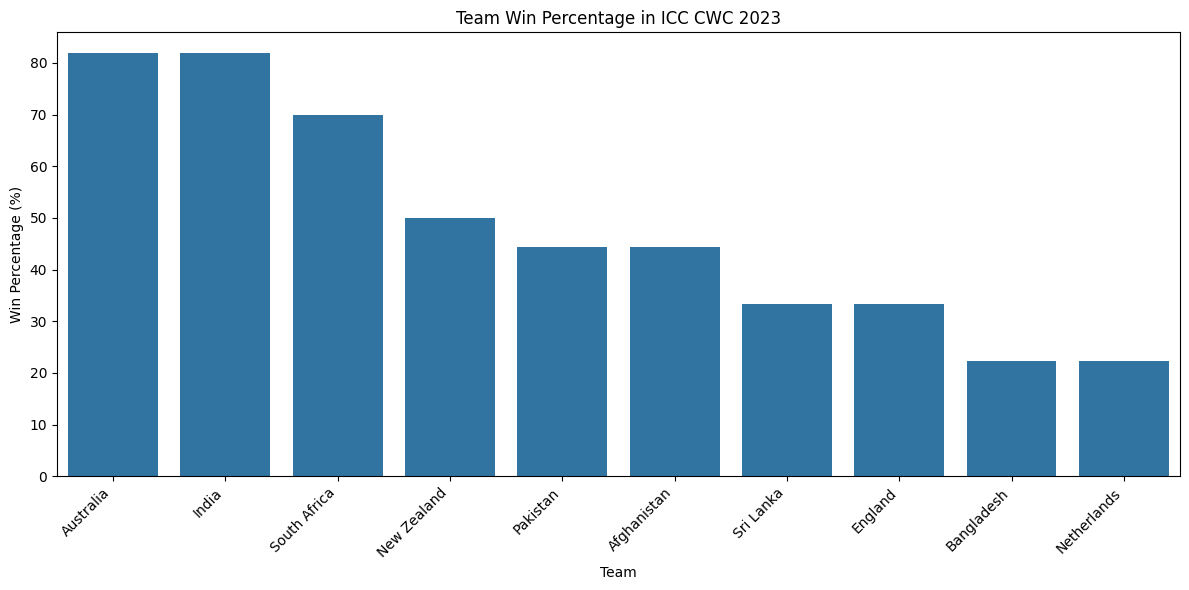

In [12]:
# Calculate wins for each team
team_wins = matches_df['winner'].value_counts()

# Calculate total matches played by each team using melt operation
team1_matches = matches_df[['team_1']].rename(columns={'team_1': 'team'})
team2_matches = matches_df[['team_2']].rename(columns={'team_2': 'team'})
all_team_matches = pd.concat([team1_matches, team2_matches])
team_matches_played = all_team_matches['team'].value_counts()

# Create win percentage DataFrame directly
win_percentage_df = pd.DataFrame({
    'Team': team_wins.index,
    'Wins': team_wins.values,
    'Matches Played': team_wins.index.map(team_matches_played),
    'Win %': (team_wins / team_wins.index.map(team_matches_played) * 100)
}).sort_values(by='Win %', ascending=False)

print("Team Win Percentage:")
print(win_percentage_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=win_percentage_df, x='Team', y='Win %')
plt.title('Team Win Percentage in ICC CWC 2023')
plt.ylabel('Win Percentage (%)')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Runs Per Wicket by Batting Order

Batting order groups created successfully!

Batting group distribution:
batting_group
Middle Order (4-7)    361
Top Order (1-3)       300
Lower Order (8+)      255
Name: count, dtype: int64
Team innings summary created with 96 records
Average Runs Per Wicket by Team:
           team  runs_per_wicket
0   New Zealand        68.889740
1         India        65.152273
2      Pakistan        56.056349
3   Afghanistan        51.717593
4     Australia        45.013440
5  South Africa        42.984080
6     Sri Lanka        31.546914
7    Bangladesh        27.102469
8       England        25.288889
9   Netherlands        19.791667


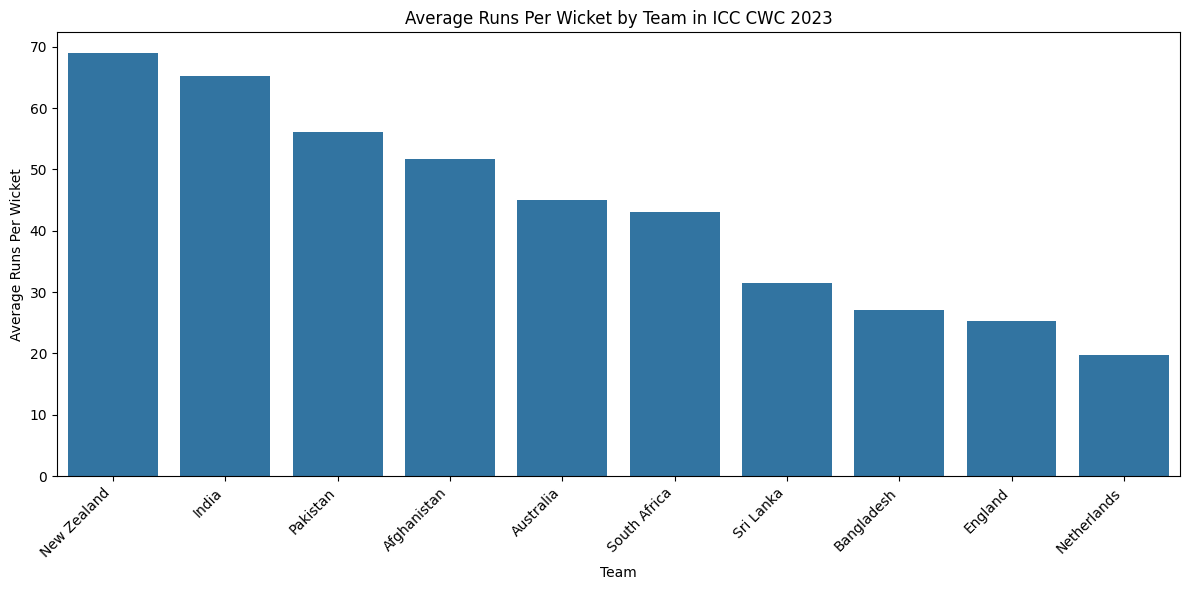

In [13]:
# Data preparation: Create batting order groups
# Ensure batting order is numeric and handle missing values
batting_df['batting_order'] = pd.to_numeric(batting_df['position'], errors='coerce').fillna(99)

def get_batting_group(order):
    """Categorize batting position into groups"""
    if order <= 3:
        return 'Top Order (1-3)'
    elif order <= 7:
        return 'Middle Order (4-7)'
    else:
        return 'Lower Order (8+)'

# Create batting group column
batting_df['batting_group'] = batting_df['batting_order'].apply(get_batting_group)

print("Batting order groups created successfully!")
print("\nBatting group distribution:")
print(batting_df['batting_group'].value_counts())

# Calculate team totals and wickets per innings
team_innings_summary = batting_df.groupby(['match_id', 'innings', 'team']).agg({
    'runs': 'sum',
    'out_or_not_out': lambda x: (x == 'out').sum()
}).reset_index()

# Rename columns for clarity
team_innings_summary.columns = ['match_id', 'innings', 'team', 'total_runs', 'wickets_lost']

# Calculate runs per wicket (handle division by zero)
team_innings_summary['runs_per_wicket'] = team_innings_summary.apply(
    lambda row: row['total_runs'] / row['wickets_lost'] if row['wickets_lost'] > 0 else row['total_runs'],
    axis=1
)

print(f"Team innings summary created with {len(team_innings_summary)} records")
team_innings_summary.head()
# Calculate average runs per wicket by team
avg_runs_per_wicket_team = (team_innings_summary
                           .groupby('team')['runs_per_wicket']
                           .mean()
                           .sort_values(ascending=False)
                           .reset_index())

print("Average Runs Per Wicket by Team:")
print(avg_runs_per_wicket_team)

# Visualize team performance
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_runs_per_wicket_team, x='team', y='runs_per_wicket')
plt.title('Average Runs Per Wicket by Team in ICC CWC 2023')
plt.ylabel('Average Runs Per Wicket')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analyze performance by batting order groups

In [14]:
batting_group_summary = batting_df.groupby(['match_id', 'innings', 'team', 'batting_group']).agg({
    'runs': 'sum',
    'out_or_not_out': lambda x: (x == 'out').sum()
}).reset_index()

# Rename columns
batting_group_summary.columns = ['match_id', 'innings', 'team', 'batting_group', 'total_runs', 'wickets_lost']

# Calculate runs per wicket for each batting group
batting_group_summary['runs_per_wicket'] = batting_group_summary.apply(
    lambda row: row['total_runs'] / row['wickets_lost'] if row['wickets_lost'] > 0 else row['total_runs'],
    axis=1
)

# Average by team and batting group
avg_runs_per_wicket_group = (batting_group_summary
                            .groupby(['team', 'batting_group'])['runs_per_wicket']
                            .mean()
                            .reset_index())

print("Average Runs Per Wicket by Batting Order Group:")
print(avg_runs_per_wicket_group.head(10))

Average Runs Per Wicket by Batting Order Group:
          team       batting_group  runs_per_wicket
0  Afghanistan    Lower Order (8+)        14.633333
1  Afghanistan  Middle Order (4-7)        48.240741
2  Afghanistan     Top Order (1-3)        45.240741
3    Australia    Lower Order (8+)        17.197917
4    Australia  Middle Order (4-7)        40.833333
5    Australia     Top Order (1-3)        48.636364
6   Bangladesh    Lower Order (8+)        16.291667
7   Bangladesh  Middle Order (4-7)        34.250000
8   Bangladesh     Top Order (1-3)        25.851852
9      England    Lower Order (8+)        19.370370


<Figure size 1200x600 with 0 Axes>

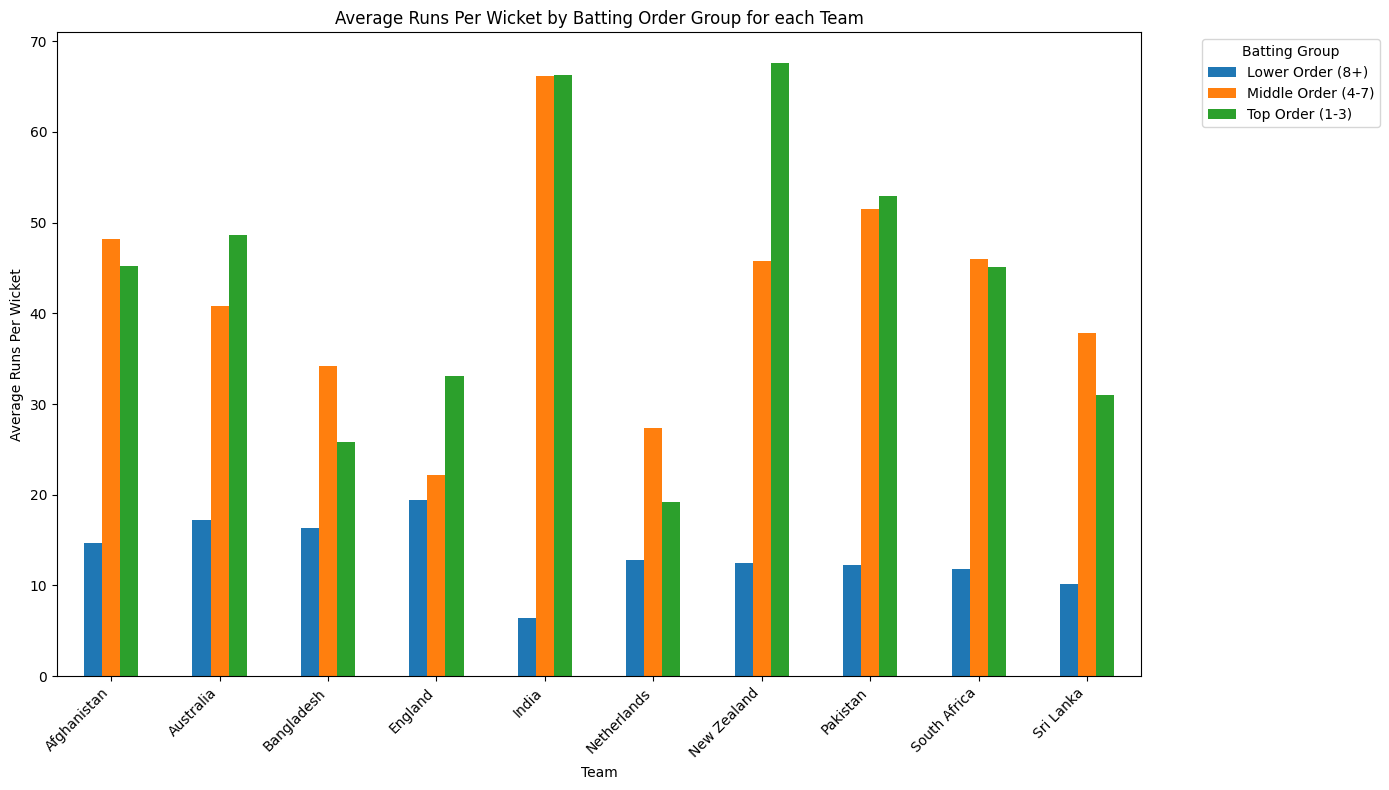

In [15]:
# Create pivot table for better visualization
avg_runs_per_wicket_pivot = (avg_runs_per_wicket_group
                            .pivot(index='team', columns='batting_group', values='runs_per_wicket')
                            .fillna(0))

# Visualize batting order performance
plt.figure(figsize=(12, 6))
avg_runs_per_wicket_pivot.plot(kind='bar', figsize=(14, 8))
plt.title('Average Runs Per Wicket by Batting Order Group for each Team')
plt.ylabel('Average Runs Per Wicket')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Batting Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Teams with 300+ Scores Analysis

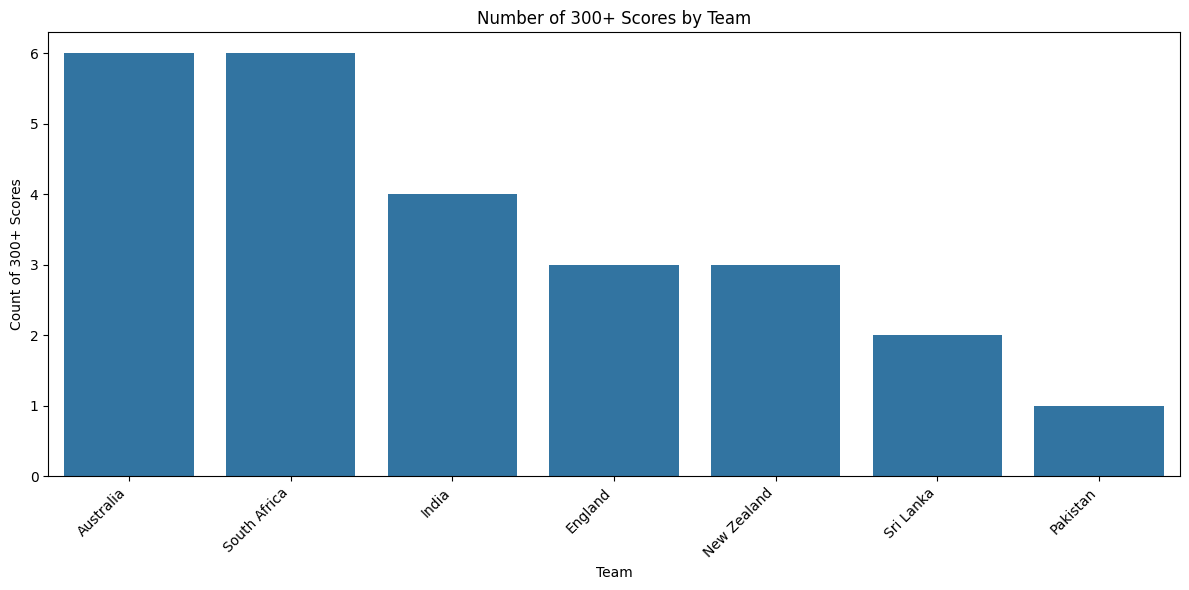

In [16]:
# Calculate team total scores per innings
team_total_scores = batting_df.groupby(['match_id', 'innings', 'team'])['runs'].sum().reset_index()

# Identify 300+ scores
team_300_plus = team_total_scores[team_total_scores['runs'] >= 300]

total_300_plus_by_team = team_300_plus.groupby('team').agg({
    'runs': ['count', 'mean', 'max']
}).round(2)

# Flatten column names
total_300_plus_by_team.columns = ['Count of 300+ Scores', 'Average Score (300+)', 'Highest Score']
total_300_plus_by_team = total_300_plus_by_team.sort_values('Count of 300+ Scores', ascending=False)

# Visualization - Count of 300+ scores
plt.figure(figsize=(12, 6))
teams = total_300_plus_by_team.index
counts = total_300_plus_by_team['Count of 300+ Scores']

sns.barplot(x=teams, y=counts)
plt.title('Number of 300+ Scores by Team')
plt.ylabel('Count of 300+ Scores')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Bowling Strength**

Total wickets by team

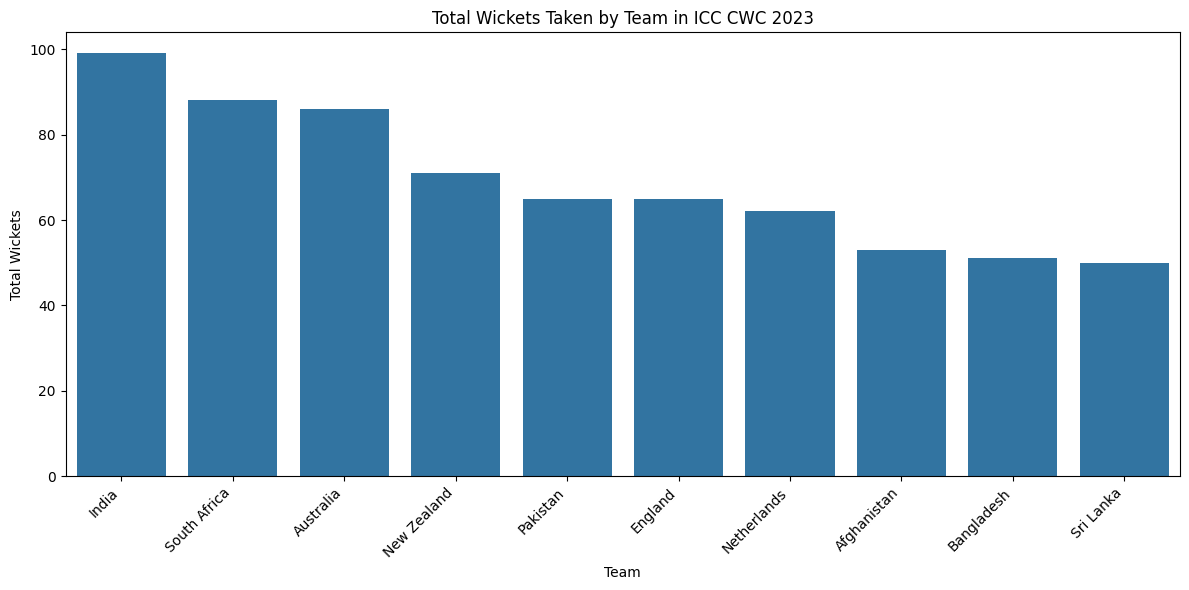

In [17]:
# Total wickets by team
total_wickets_by_team = bowling_df.groupby('team')['wickets'].sum().sort_values(ascending=False).reset_index()
total_wickets_by_team.rename(columns={'team': 'Team'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=total_wickets_by_team, x='Team', y='wickets')
plt.title('Total Wickets Taken by Team in ICC CWC 2023')
plt.ylabel('Total Wickets')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Economy Rate Analysis

In [18]:
# Calculate team bowling statistics
team_bowling_stats = bowling_df.groupby('team').agg(
    total_wickets=('wickets', 'sum'),
    total_runs_conceded=('runs', 'sum'),
    total_overs_bowled=('overs', 'sum'),
    total_maidens=('maidens', 'sum'),
    matches_played=('match_id', 'nunique')
).reset_index()

# Calculate derived statistics
team_bowling_stats['average_bowling_avg'] = team_bowling_stats['total_runs_conceded'] / team_bowling_stats['total_wickets'].replace(0, 1)
team_bowling_stats['average_economy'] = team_bowling_stats['total_runs_conceded'] / team_bowling_stats['total_overs_bowled'].replace(0, 1)
team_bowling_stats['average_strike_rate'] = (team_bowling_stats['total_overs_bowled'] * 6) / team_bowling_stats['total_wickets'].replace(0, 1)

# Rename team column for consistency
team_bowling_stats.rename(columns={'team': 'Team'}, inplace=True)

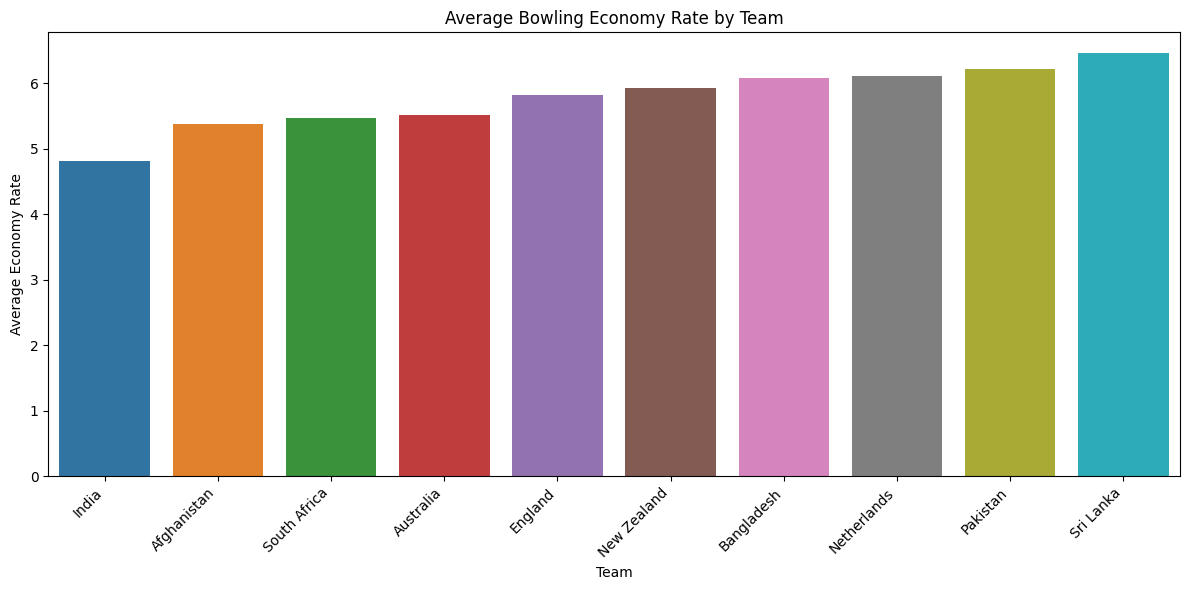

In [19]:
economy_sorted = team_bowling_stats.sort_values(by='average_economy')

plt.figure(figsize=(12, 6))
sns.barplot(data=economy_sorted, x='Team', y='average_economy', hue='Team', legend=False)
plt.title('Average Bowling Economy Rate by Team')
plt.ylabel('Average Economy Rate')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Players (Batsmen and Bowlers)

Top 10 Run Scorers

In [20]:
# Calculate comprehensive batsman statistics
batsman_stats = batting_df.groupby('batsman').agg(
    total_runs=('runs', 'sum'),
    matches_played=('match_id', 'nunique'),
    innings_played=('runs', 'count'),
    times_out=('out_or_not_out', lambda x: (x == 'out').sum()),
    times_not_out=('out_or_not_out', lambda x: (x == 'not out').sum()),
    highest_score=('runs', 'max'),
    total_balls=('balls', 'sum'),
    total_fours=('fours', 'sum'),
    total_sixes=('sixes', 'sum')
).reset_index()

# Rename the batsman column for consistency
batsman_stats.rename(columns={'batsman': 'Batsman_Name'}, inplace=True)

# Calculate derived statistics
batsman_stats['average'] = batsman_stats['total_runs'] / batsman_stats['times_out'].replace(0, 1)
batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / batsman_stats['total_balls'].replace(0, 1)) * 100

# Count centuries and half-centuries
batsman_stats['hundreds'] = batting_df.groupby('batsman')['runs'].apply(lambda x: (x >= 100).sum()).values
batsman_stats['fifties'] = batting_df.groupby('batsman')['runs'].apply(lambda x: ((x >= 50) & (x < 100)).sum()).values

# Fill NaN values with 0 for cleaner output
batsman_stats = batsman_stats.fillna(0)

print("Batsman statistics calculated successfully!")
print(f"Total batsmen: {len(batsman_stats)}")
print(batsman_stats.head())

Batsman statistics calculated successfully!
Total batsmen: 146
        Batsman_Name  total_runs  matches_played  innings_played  times_out  \
0  Abdullah Shafique         336               8               8          8   
1         Adam Zampa          59               7               7          4   
2        Adil Rashid          92               9               9          6   
3        Agha Salman          51               1               1          1   
4      Aiden Markram         472              10              12         12   

   times_not_out  highest_score  total_balls  total_fours  total_sixes  \
0              0            113          360           36            9   
1              3             29           76            6            0   
2              3             20           91            7            2   
3              0             51           45            6            1   
4              0            106          430           53           10   

     average  str

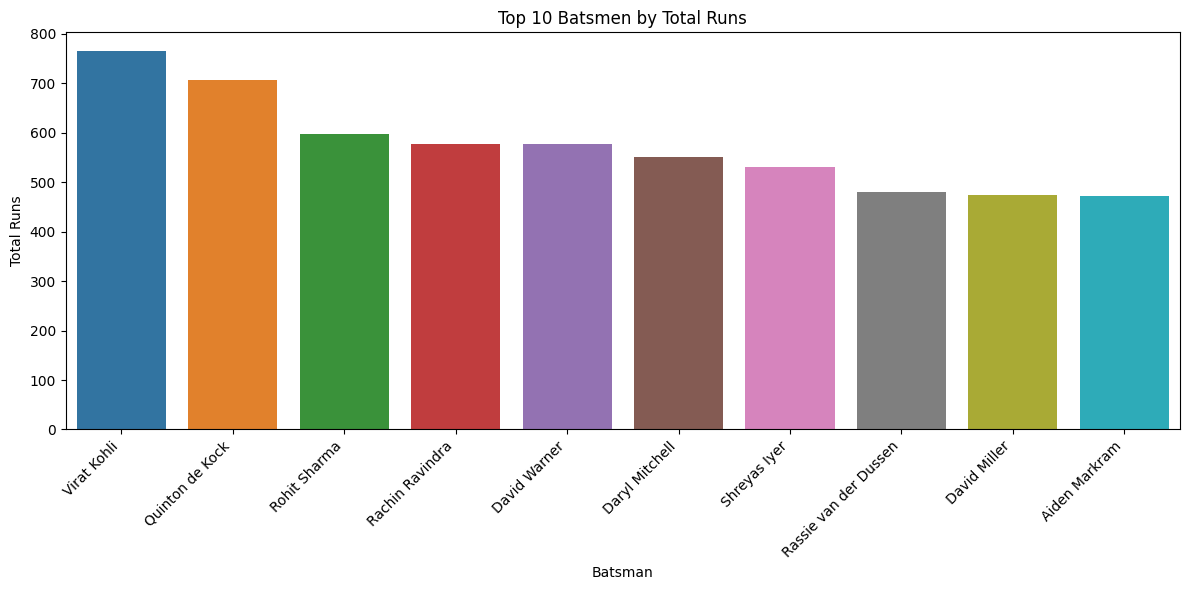

In [21]:
# Top 10 by total runs
top_runs = batsman_stats.nlargest(10, 'total_runs')[['Batsman_Name', 'total_runs', 'average', 'strike_rate', 'hundreds', 'fifties']]

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_runs, x='Batsman_Name', y='total_runs', hue='Batsman_Name', legend=False)
plt.title('Top 10 Batsmen by Total Runs')
plt.ylabel('Total Runs')
plt.xlabel('Batsman')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Highest Strike Rates

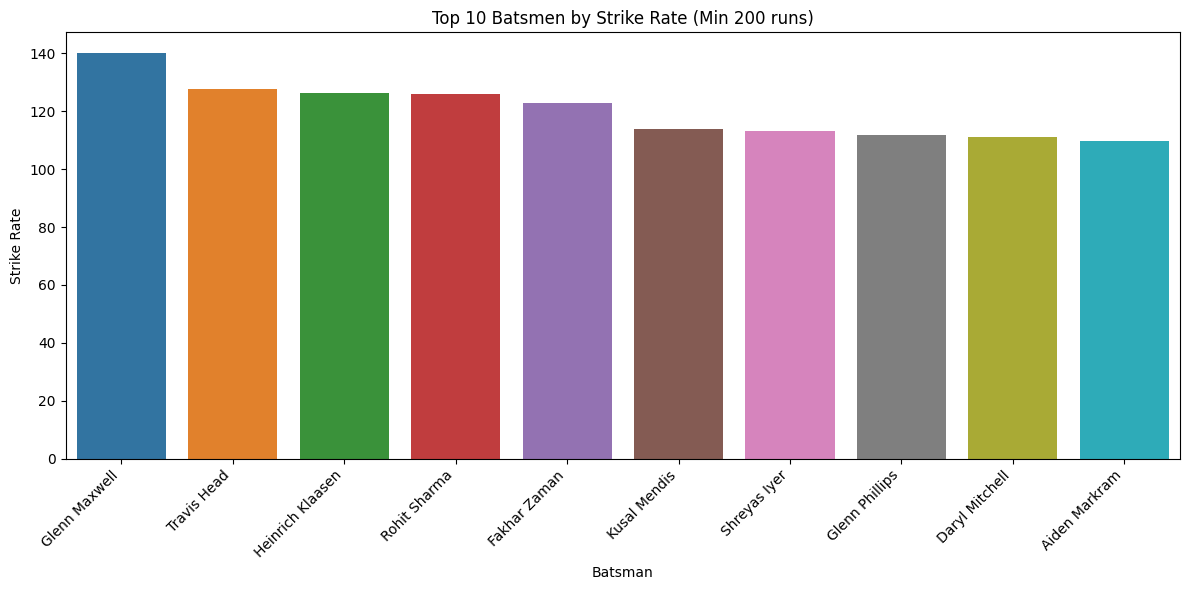

In [22]:
# Top 10 by strike rate (minimum 200 runs)
top_sr = batsman_stats[batsman_stats['total_runs'] >= 200].nlargest(10, 'strike_rate')[['Batsman_Name', 'total_runs', 'average', 'strike_rate', 'total_fours', 'total_sixes']]

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sr, x='Batsman_Name', y='strike_rate', hue='Batsman_Name', legend=False)
plt.title('Top 10 Batsmen by Strike Rate (Min 200 runs)')
plt.ylabel('Strike Rate')
plt.xlabel('Batsman')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Most Centuries and Half-Centuries

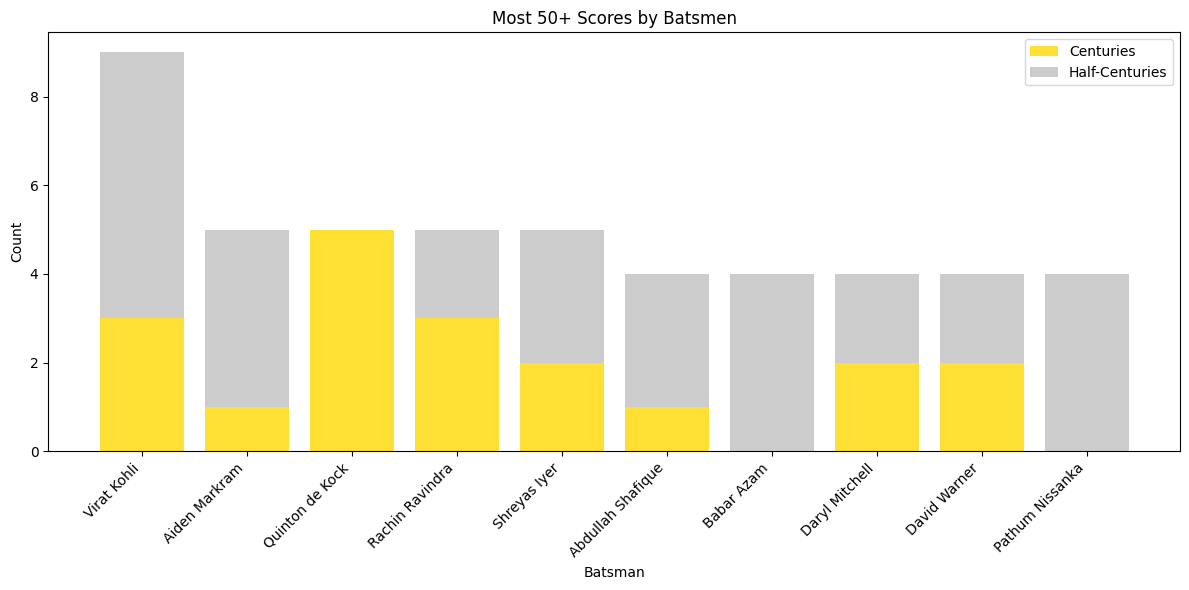

In [23]:
# Players with most half-centuries
most_fifties = batsman_stats.nlargest(10, 'fifties')[['Batsman_Name', 'fifties', 'hundreds', 'total_runs', 'average']]

# Visualization for 50+ scores
batsman_stats['total_50_plus'] = batsman_stats['hundreds'] + batsman_stats['fifties']
top_50_plus = batsman_stats.nlargest(10, 'total_50_plus')

plt.figure(figsize=(12, 6))
x_pos = range(len(top_50_plus))
plt.bar(x_pos, top_50_plus['hundreds'], label='Centuries', alpha=0.8, color='gold')
plt.bar(x_pos, top_50_plus['fifties'], bottom=top_50_plus['hundreds'],
        label='Half-Centuries', alpha=0.8, color='silver')

plt.title('Most 50+ Scores by Batsmen')
plt.ylabel('Count')
plt.xlabel('Batsman')
plt.xticks(x_pos, top_50_plus['Batsman_Name'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**Top 10 Bowlers**

Top 10 Wicket Takers

In [24]:
# Calculate comprehensive bowler statistics
bowler_stats = bowling_df.groupby('bowler').agg(
    total_wickets=('wickets', 'sum'),
    total_runs_conceded=('runs', 'sum'),
    total_overs=('overs', 'sum'),
    total_maidens=('maidens', 'sum'),
    matches_played=('match_id', 'nunique'),
    innings_bowled=('wickets', 'count')
).reset_index()

# Rename the bowler column for consistency
bowler_stats.rename(columns={'bowler': 'Bowler_Name'}, inplace=True)

# Calculate derived statistics
bowler_stats['bowling_average'] = bowler_stats['total_runs_conceded'] / bowler_stats['total_wickets'].replace(0, 1)
bowler_stats['economy_rate'] = bowler_stats['total_runs_conceded'] / bowler_stats['total_overs'].replace(0, 1)
bowler_stats['strike_rate'] = (bowler_stats['total_overs'] * 6) / bowler_stats['total_wickets'].replace(0, 1)

# Calculate best bowling figures
bowler_best_figures = bowling_df.loc[bowling_df.groupby('bowler')['wickets'].idxmax()][['bowler', 'wickets', 'runs']]
bowler_best_figures.rename(columns={'bowler': 'Bowler_Name', 'wickets': 'best_figures_wickets', 'runs': 'best_figures_runs'}, inplace=True)

# Merge best figures with main stats
bowler_stats = pd.merge(bowler_stats, bowler_best_figures, on='Bowler_Name', how='left')

# Fill NaN values with 0 for cleaner output
bowler_stats = bowler_stats.fillna(0)

print("Bowler statistics calculated successfully!")
print(f"Total bowlers: {len(bowler_stats)}")
print(bowler_stats.head())

Bowler statistics calculated successfully!
Total bowlers: 102
          Bowler_Name  total_wickets  total_runs_conceded  total_overs  \
0          Adam Zampa             23                  515         96.0   
1         Adil Rashid             15                  413         79.4   
2         Agha Salman              0                   46          5.0   
3       Aiden Markram              1                   85         18.3   
4  Andile Phehlukwayo              1                   36          7.0   

   total_maidens  matches_played  innings_bowled  bowling_average  \
0              1              11              11        22.391304   
1              1               9               9        27.533333   
2              0               2               2        46.000000   
3              1               4               4        85.000000   
4              0               1               1        36.000000   

   economy_rate  strike_rate  best_figures_wickets  best_figures_runs  
0     

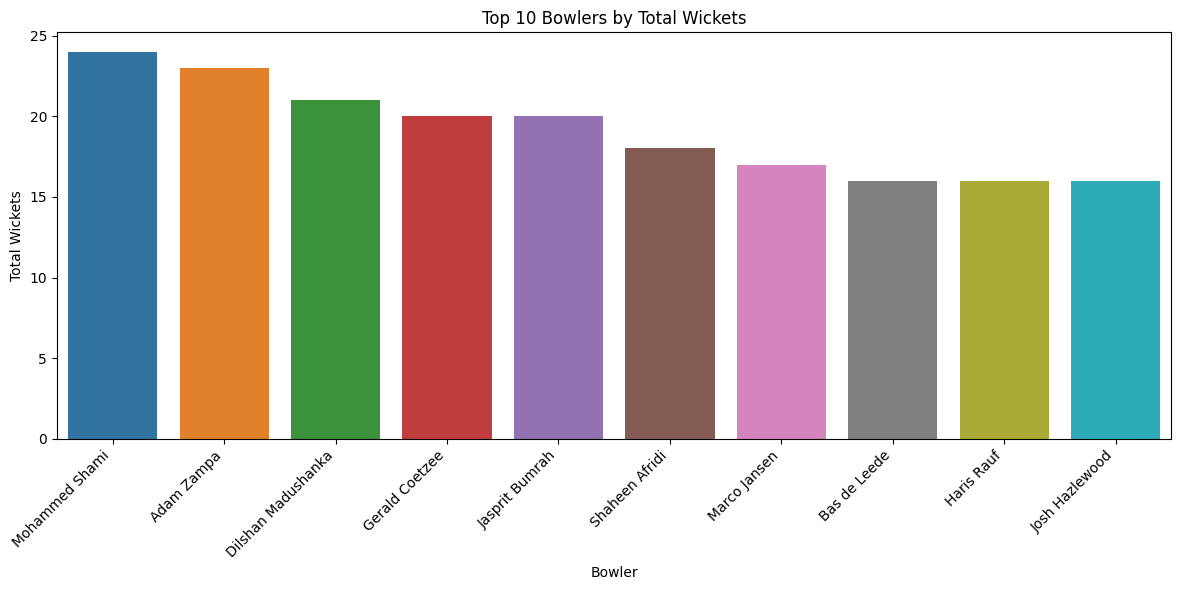

In [25]:
# Top 10 by total wickets
top_wickets = bowler_stats.nlargest(10, 'total_wickets')[['Bowler_Name', 'total_wickets', 'bowling_average', 'economy_rate', 'strike_rate', 'best_figures_wickets']]

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_wickets, x='Bowler_Name', y='total_wickets', hue='Bowler_Name', legend=False)
plt.title('Top 10 Bowlers by Total Wickets')
plt.ylabel('Total Wickets')
plt.xlabel('Bowler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Best Economy Rates

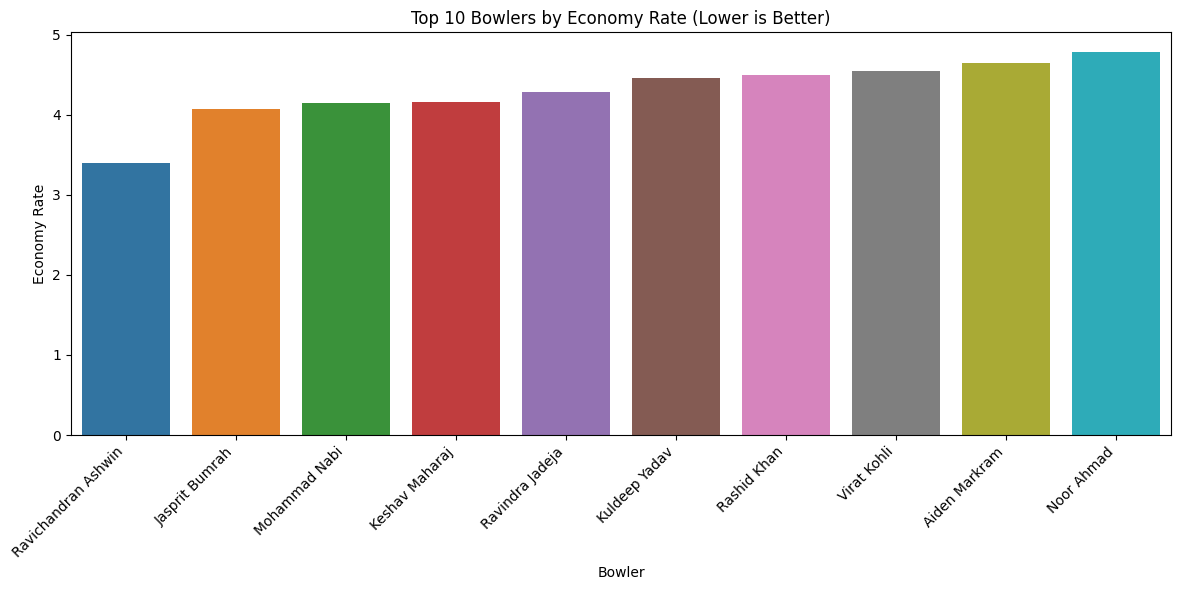

In [26]:
# Top 10 by economy rate
best_economy = bowler_stats.nsmallest(10, 'economy_rate')[['Bowler_Name', 'total_wickets', 'bowling_average', 'economy_rate', 'total_maidens']]

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=best_economy, x='Bowler_Name', y='economy_rate', hue='Bowler_Name', legend=False)
plt.title('Top 10 Bowlers by Economy Rate (Lower is Better)')
plt.ylabel('Economy Rate')
plt.xlabel('Bowler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Best Strike Rates

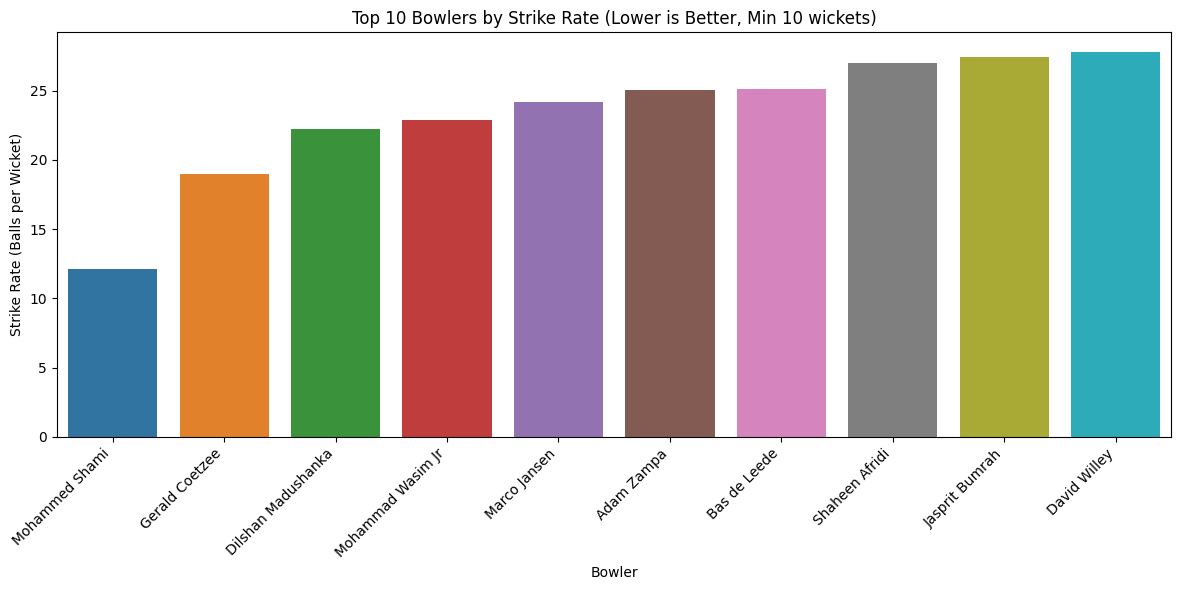

In [27]:
# Top 10 by strike rate (minimum 10 wickets)
best_sr = bowler_stats[bowler_stats['total_wickets'] >= 10].nsmallest(10, 'strike_rate')[['Bowler_Name', 'total_wickets', 'bowling_average', 'economy_rate', 'strike_rate']]

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=best_sr, x='Bowler_Name', y='strike_rate', hue='Bowler_Name', legend=False)
plt.title('Top 10 Bowlers by Strike Rate (Lower is Better, Min 10 wickets)')
plt.ylabel('Strike Rate (Balls per Wicket)')
plt.xlabel('Bowler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()